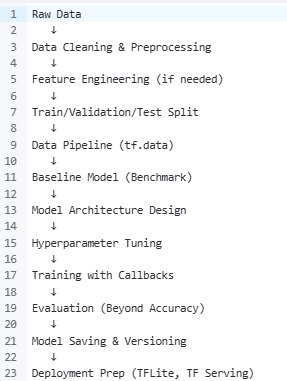

##Data Preprocessing (The Foundation)

In [ ]:
import pandas as pd
df = df.dropna()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

le = LabelEncoder()
y = le.fit_transform(y)

y_cat = tf.keras.utils.to_categorical(y,num_classes= 10)

##Feature Engineering

In [ ]:
df['age_income_ratio'] = df['age']/(df['income']+1)
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month
df['year'] = df['timestamp'].dt.year
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['hour_of_day'] = df['timestamp'].dt.hour

In [ ]:
img = tf.image.resize(img,[224,224])

In [ ]:
#For Text:
#Clean text (remove punctuation, lowercasing)
#Tokenization, padding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
tokenizer = Tokenizer(num_wors = 10000)
tokenizer.fit_on_texts(texts)
seqs = tokenizer.text.to_sequences(texts)
padded_seqs = pad_sequences(seqs,maxlen = 100)

## tf.data (data pipeline)

In [ ]:
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Create dataset
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.map(preprocess)
train_ds = train_ds.shuffle(1000).batch(32).prefetch(1)

# For large datasets (e.g., from disk)
train_ds = tf.keras.utils.image_dataset_from_directory(
    'data/train/',
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

In [ ]:
#benchmark
model_baseline = Sequential([
    Flatten(input_shape= (28,28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
model.baseline.compile(optimizer = 'adma',loss = 'sparse_categorical_crossentorpy',
                       metrics = ['accuracy'])
history = model_baseline.fit(train_ds, epochs=3, validation_data=val_ds)

In [ ]:
#better Model
model = Sequential([
    Conv2D(32, 3, activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(),
    Conv2D(64, 3, activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

In [ ]:
#Add Regularization (Avoid Overfitting)
Dropout(0.5)           # Randomly zero 50% of neurons
BatchNormalization()   # Stabilize training
L2 regularization      # model.add(Dense(64, kernel_regularizer='l2'))

In [ ]:
#Hyperparameter tuning
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
#Automated
import keras_tuner as kt

def build_model(hp):
    model = Sequential()
    model.add(Flatten(input_shape=(28,28)))
    for i in range(hp.Int('n_layers', 1, 3)):
        model.add(Dense(
            hp.Int(f'units_{i}', 32, 512, step=32),
            activation='relu'
        ))
        model.add(Dropout(0.2))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
    return model

tuner = kt.RandomSearch(build_model, objective='val_loss', max_trials=10)
tuner.search(train_ds, epochs=5, validation_data=val_ds)
best_model = tuner.get_best_models()[0]


In [ ]:
#Model Evaluation (Beyond Accuracy)
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy', 'precision', 'recall']
)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d')
print(classification_report(y_test, y_pred_classes))

from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}')

from sklearn.model_selection import train_test_split

# For structured data
x_temp, x_test, y_temp, y_test = train_test_split(x, y, test_size=0.2)
x_train, x_val, y_train, y_val = train_test_split(x_temp, y_temp, test_size=0.25)

# For images: use directory structure or tf.data

In [ ]:
#Callbacks (Smart Training)
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.h5',
        monitor='val_accuracy',
        save_best_only=True
    ),
    tf.keras.callbacks.TensorBoard(log_dir='./logs')
]

In [ ]:
model.fit(train_ds, validation_data=val_ds, epochs=50, callbacks=callbacks)

In [ ]:
model.save('my_model')                  # SavedModel (recommended)
model.save('my_model.h5')               # HDF5

In [ ]:
loaded_model = tf.keras.models.load_model('my_model')

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
open('model.tflite', 'wb').write(tflite_model)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1686/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8595 - loss: 0.4393 - precision: 0.9293 - recall: 0.8049

1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 30ms/step - accuracy: 0.8596 - loss: 0.4389 - precision: 0.9294 - recall: 0.8051 - val_accuracy: 0.9825 - val_loss: 0.0542 - val_precision: 0.9867 - val_recall: 0.9802 - learning_rate: 0.0010
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9736 - loss: 0.0901 - precision: 0.9784 - recall: 0.9704

1688/1688 ━━━━━━━━━━━━━━━━━━━━ 50s 29ms/step - accuracy: 0.9736 - loss: 0.0901 - precision: 0.9784 - recall: 0.9704 - val_accuracy: 0.9883 - val_loss: 0.0377 - val_precision: 0.9911 - val_recall: 0.9872 - learning_rate: 0.0010
Epoch 3/10
1687/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9803 - loss: 0.0654 - precision: 0.9830 - recall: 0.9784

1688/1688 ━━━━━━━━━━━━━━━━━━━━ 49s 29ms/step - accuracy: 0.9803 - loss: 0.0654 - precision: 0.9830 - recall: 0.9784 - val_accuracy: 0.9913 - val_loss: 0.0288 - val_precision: 0.9925 - val_recall: 0.9905 - learning_rate: 0.0010
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 29ms/step - accuracy: 0.9848 - loss: 0.0497 - precision: 0.9863 - recall: 0.9829 - val_accuracy: 0.9907 - val_loss: 0.0312 - val_precision: 0.9913 - val_recall: 0.9903 - learning_rate: 0.0010
Epoch 5/10
1687/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9874 - loss: 0.0402 - precision: 0.9884 - recall: 0.9861

1688/1688 ━━━━━━━━━━━━━━━━━━━━ 50s 30ms/step - accuracy: 0.9874 - loss: 0.0402 - precision: 0.9884 - recall: 0.9861 - val_accuracy: 0.9922 - val_loss: 0.0260 - val_precision: 0.9933 - val_recall: 0.9912 - learning_rate: 0.0010
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 30ms/step - accuracy: 0.9885 - loss: 0.0358 - precision: 0.9896 - recall: 0.9875 - val_accuracy: 0.9923 - val_loss: 0.0289 - val_precision: 0.9928 - val_recall: 0.9918 - learning_rate: 0.0010
Epoch 7/10
1687/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9899 - loss: 0.0310 - precision: 0.9912 - recall: 0.9890

1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 29ms/step - accuracy: 0.9899 - loss: 0.0310 - precision: 0.9912 - recall: 0.9890 - val_accuracy: 0.9930 - val_loss: 0.0259 - val_precision: 0.9937 - val_recall: 0.9920 - learning_rate: 0.0010
Epoch 8/10
1686/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9933 - loss: 0.0208 - precision: 0.9939 - recall: 0.9925

1688/1688 ━━━━━━━━━━━━━━━━━━━━ 49s 29ms/step - accuracy: 0.9933 - loss: 0.0208 - precision: 0.9939 - recall: 0.9925 - val_accuracy: 0.9933 - val_loss: 0.0229 - val_precision: 0.9937 - val_recall: 0.9932 - learning_rate: 1.0000e-04
Epoch 9/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 29ms/step - accuracy: 0.9953 - loss: 0.0144 - precision: 0.9957 - recall: 0.9950 - val_accuracy: 0.9938 - val_loss: 0.0243 - val_precision: 0.9947 - val_recall: 0.9938 - learning_rate: 1.0000e-04
Epoch 10/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 53s 32ms/step - accuracy: 0.9966 - loss: 0.0114 - precision: 0.9971 - recall: 0.9962 - val_accuracy: 0.9938 - val_loss: 0.0249 - val_precision: 0.9940 - val_recall: 0.9935 - learning_rate: 1.0000e-04
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99   

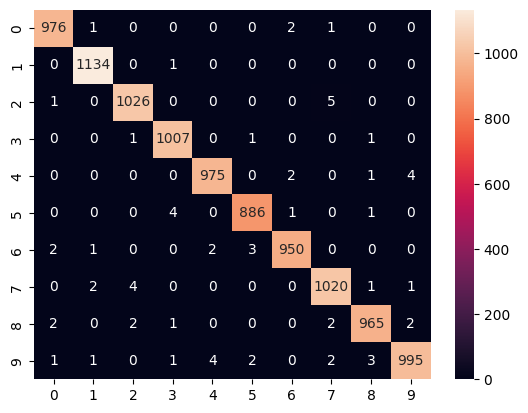

🎉 Model saved successfully!


In [2]:
# Full MNIST CNN Project - Professional Style
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import *
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from sklearn.model_selection import train_test_split

# 1. Load data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 2. Preprocess
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

# 3. Split
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.1)

# 4. Data pipeline
def make_ds(x, y, batch_size=32, shuffle=False):
    y = tf.one_hot(y, depth=10) # One-hot encode the labels
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle: ds = ds.shuffle(1000)
    return ds.batch(batch_size).prefetch(1)

train_ds = make_ds(x_train, y_train, shuffle=True)
val_ds   = make_ds(x_val, y_val)
test_ds  = make_ds(x_test, y_test)

# 5. Build model
model = Sequential([
    Conv2D(32, 3, activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(),
    Conv2D(64, 3, activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# 6. Compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy', # Use categorical_crossentropy for one-hot encoded labels
              metrics=['accuracy', 'precision', 'recall'])

# 7. Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('best_mnist.h5', save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, min_lr=1e-7)
]

# 8. Train
history = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=callbacks)

# 9. Evaluate
y_pred = model.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)

# We need the original y_test for classification_report and confusion_matrix
y_test_original = np.concatenate([y for x, y in test_ds], axis=0)


print(classification_report(np.argmax(y_test_original, axis=1), y_pred_classes))

cm = confusion_matrix(np.argmax(y_test_original, axis=1), y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()


# 10. Save
model.save('mnist_cnn_final.h5')
print("🎉 Model saved successfully!")